In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 

In [2]:
df=pd.read_csv('C:\\Users\\LoQ\\Desktop\\new_ vital sign\\Human_vital_signs_R.csv')

In [3]:
df.describe()

,Unnamed: 0,Time (s),HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C)
count,25493.000000,25493.000000,25488.000000,25346.000000,25366.000000,25493.000000
mean,240.000000,239.981132,89.127943,17.640496,96.716471,37.590123
std,138.855163,138.855230,13.220448,3.589381,3.323381,5.211265
min,0.000000,-1.000000,44.000000,0.000000,83.000000,21.000000
25%,120.000000,120.000000,81.000000,16.000000,95.000000,34.000000
50%,240.000000,240.000000,89.000000,18.000000,97.000000,38.000000
75%,360.000000,360.000000,95.000000,20.000000,99.000000,41.000000
max,480.000000,480.000000,139.000000,34.000000,111.000000,49.000000


In [4]:
df_out=df.copy()

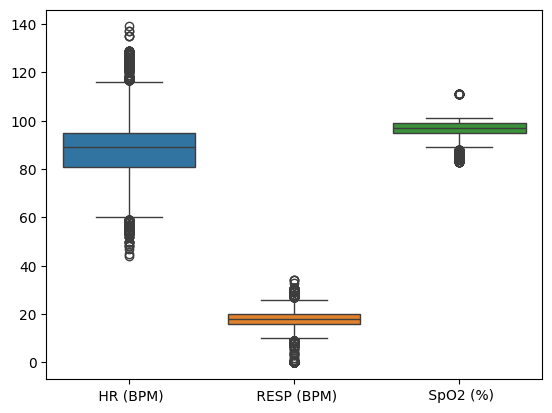

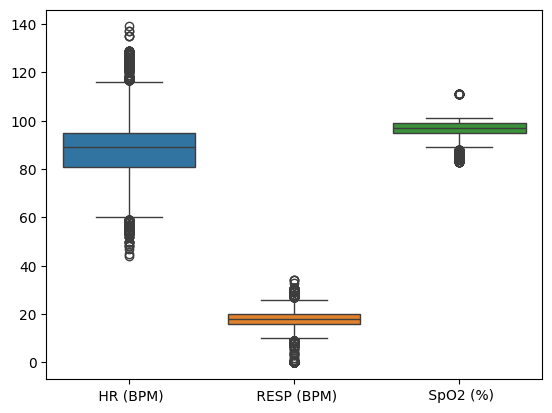

In [5]:
sns.boxplot(df_out[[' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)']] )
plt.show()
sns.boxplot(df[[' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)']] )
plt.show()

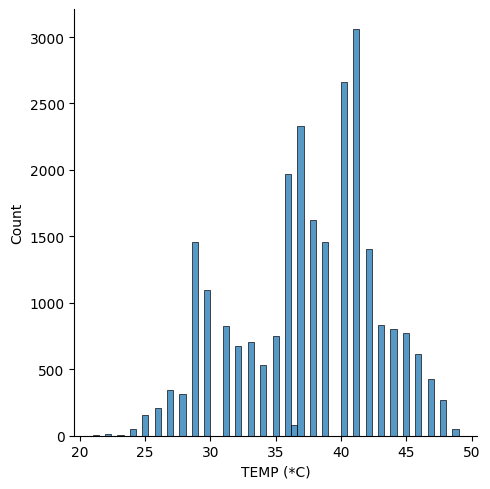

In [6]:
sns.displot(df['TEMP (*C)'])

In [7]:
df=df[df[' SpO2 (%)']<=100]
df=df[df[' RESP (BPM)']!=0]
df=df[df['TEMP (*C)']>=29]
df=df[df['TEMP (*C)']<=43]

In [8]:
df.describe()

,Unnamed: 0,Time (s),HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C)
count,21132.000000,21132.000000,21127.000000,20991.000000,21132.000000,21132.000000
mean,245.157108,245.135340,89.409381,17.817398,96.684460,37.054704
std,139.519868,139.520458,13.136681,3.235516,3.283362,4.114771
min,0.000000,-1.000000,44.000000,1.000000,83.000000,29.000000
25%,124.000000,124.000000,81.000000,16.000000,95.000000,35.000000
50%,250.000000,250.000000,89.000000,18.000000,97.000000,38.000000
75%,366.000000,366.000000,95.000000,20.000000,99.000000,40.000000
max,480.000000,480.000000,139.000000,34.000000,100.000000,43.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21132 entries, 0 to 25492
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   21132 non-null  int64  
 1   Time (s)     21132 non-null  int64  
 2    HR (BPM)    21127 non-null  float64
 3    RESP (BPM)  20991 non-null  float64
 4    SpO2 (%)    21132 non-null  float64
 5   TEMP (*C)    21132 non-null  float64
 6   OUTPUT       21132 non-null  object 
dtypes: float64(4), int64(2), object(1)
memory usage: 1.3+ MB


In [10]:
df['OUTPUT'].value_counts()

OUTPUT
Abnormal    16422
Normal       4710
Name: count, dtype: int64

In [11]:
df['OUTPUT'] = df['OUTPUT'].replace({'Abnormal': 1, 'Normal': 0})

C:\Users\LoQ\AppData\Local\Temp\ipykernel_12844\2056500274.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['OUTPUT'] = df['OUTPUT'].replace({'Abnormal': 1, 'Normal': 0})


missing value

In [12]:
df.isnull().sum()

Unnamed: 0       0
Time (s)         0
 HR (BPM)        5
 RESP (BPM)    141
 SpO2 (%)        0
TEMP (*C)        0
OUTPUT           0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

Unnamed: 0     0
Time (s)       0
 HR (BPM)      0
 RESP (BPM)    0
 SpO2 (%)      0
TEMP (*C)      0
OUTPUT         0
dtype: int64

In [15]:
df.drop(columns=['Time (s)','Unnamed: 0'],inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20986 entries, 0 to 25492
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0    HR (BPM)    20986 non-null  float64
 1    RESP (BPM)  20986 non-null  float64
 2    SpO2 (%)    20986 non-null  float64
 3   TEMP (*C)    20986 non-null  float64
 4   OUTPUT       20986 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 983.7 KB


outlier

In [17]:
def count_outliers_iqr(df):
    outlier_count = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count[col] = len(outliers)
    return outlier_count

# Count outliers in the DataFrame
outliers = count_outliers_iqr(df)
print("Outlier count per column:")
print(outliers)

Outlier count per column:
{' HR (BPM)': 1513, ' RESP (BPM)': 278, ' SpO2 (%)': 777, 'TEMP (*C)': 0, 'OUTPUT': 4707}


<Axes: ylabel=' HR (BPM)'>

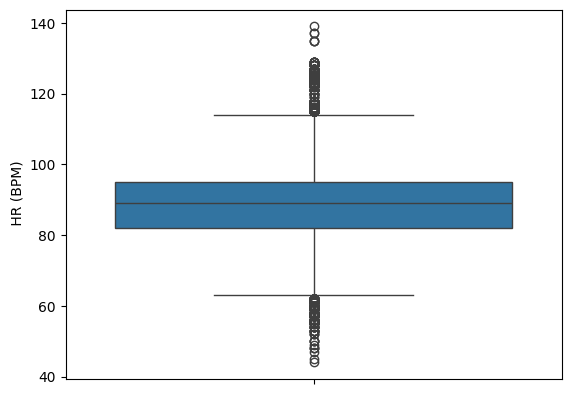

In [18]:
sns.boxplot(df[' HR (BPM)'])

heart rate 

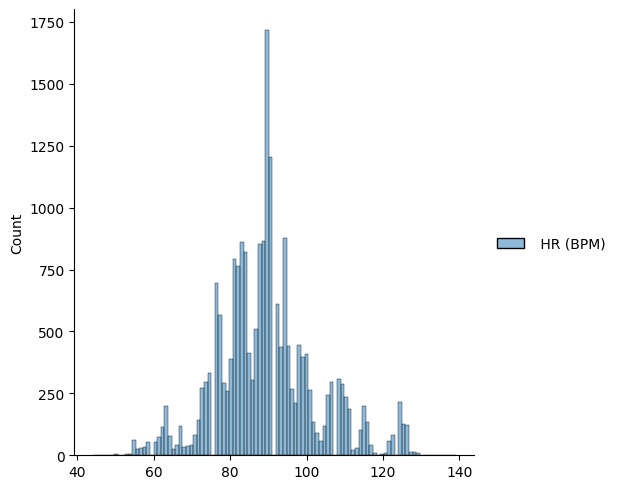

In [19]:
sns.displot(df[[' HR (BPM)']])

In [20]:
print('HR normal value ', ((df[' HR (BPM)'] > 60) & (df[' HR (BPM)'] < 100) & (df['OUTPUT'] == 0)).sum())

HR normal value  4289


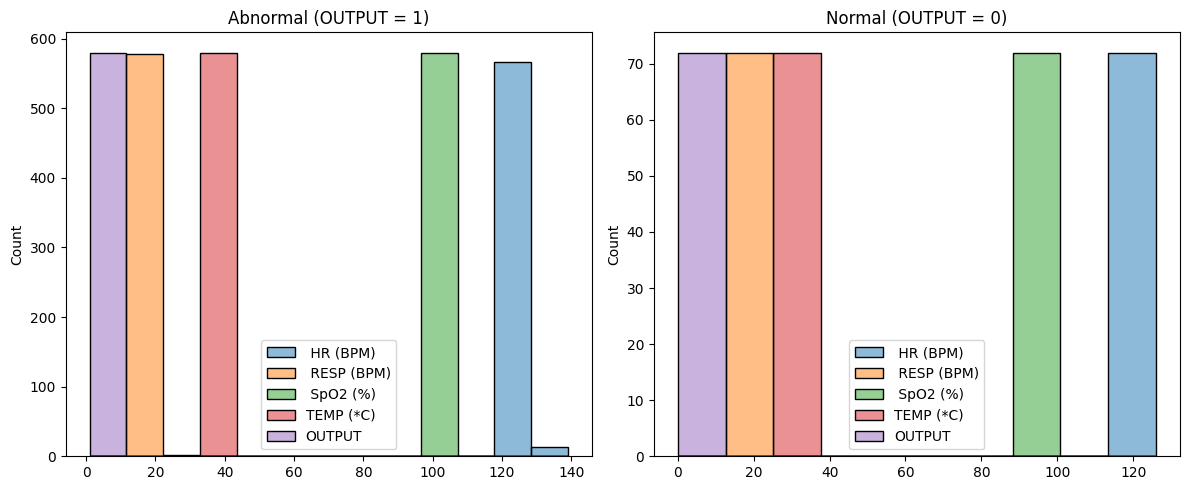

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[(df[' HR (BPM)'] > 120) & (df['OUTPUT'] == 1)])
plt.title('Abnormal (OUTPUT = 1)')

plt.subplot(1, 2, 2)
sns.histplot(df[(df[' HR (BPM)'] > 120) & (df['OUTPUT'] == 0)])
plt.title('Normal (OUTPUT = 0)')

plt.tight_layout()
plt.show()


In [22]:
df=df[(df[' HR (BPM)'] < 120)]
#20986-(580+78)

In [23]:

df[' HR (BPM)'].describe()

count    20328.000000
mean        88.423554
std         11.618260
min         44.000000
25%         81.000000
50%         89.000000
75%         94.000000
max        119.000000
Name:  HR (BPM), dtype: float64

<Axes: ylabel=' HR (BPM)'>

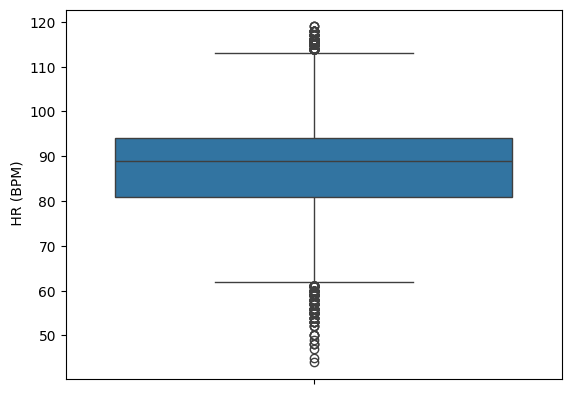

In [24]:
sns.boxplot(df[' HR (BPM)'])

2514


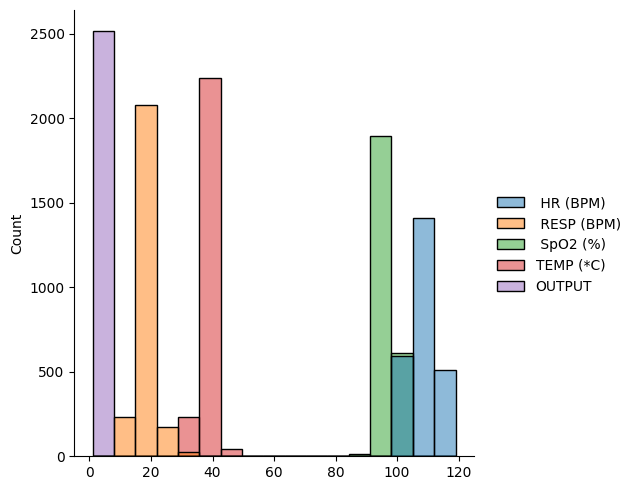

In [25]:
sns.displot(df[(df[' HR (BPM)'] > 100) & (df['OUTPUT'] == 1)])
print(((df[' HR (BPM)'] > 100) & (df['OUTPUT'] == 1)).sum())

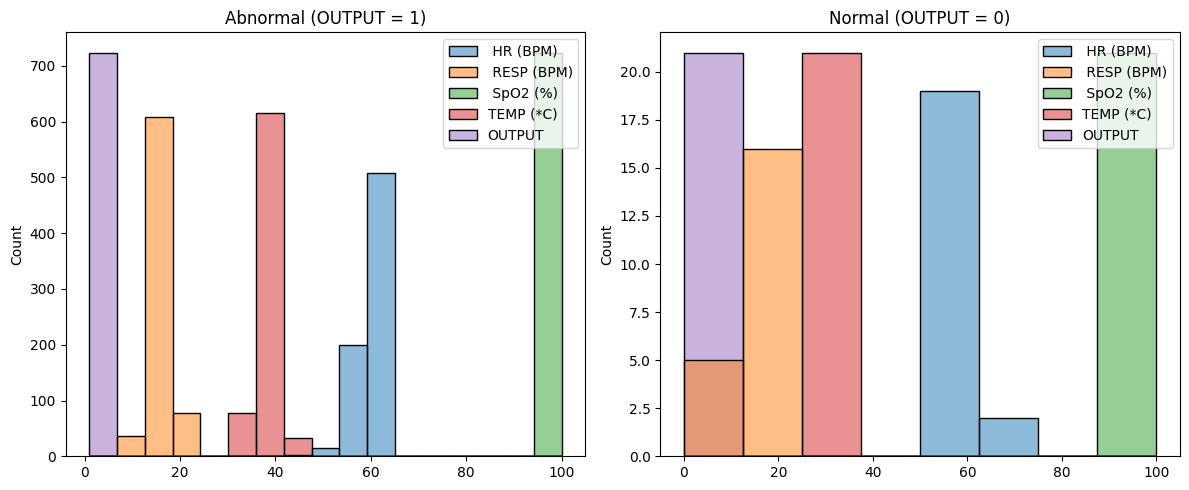

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[(df[' HR (BPM)'] < 65) & (df['OUTPUT'] == 1)])
plt.title('Abnormal (OUTPUT = 1)')

plt.subplot(1, 2, 2)
sns.histplot(df[(df[' HR (BPM)'] < 65) & (df['OUTPUT'] == 0)])
plt.title('Normal (OUTPUT = 0)')

plt.tight_layout()
plt.show()


In [27]:
df=df[(df[' HR (BPM)'] < 65) & (df['OUTPUT'] == 1 )|(df[' HR (BPM)'] >= 65)]

In [28]:
((df[' HR (BPM)'] < 65) & (df['OUTPUT'] == 0)).sum()
#20328-21=20307

np.int64(0)

In [29]:
df[' HR (BPM)'].describe()

count    20307.000000
mean        88.456148
std         11.579222
min         44.000000
25%         81.000000
50%         89.000000
75%         94.000000
max        119.000000
Name:  HR (BPM), dtype: float64

<Axes: ylabel=' HR (BPM)'>

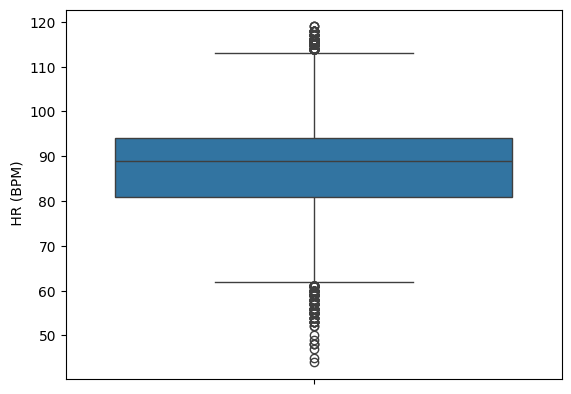

In [30]:
sns.boxplot(df[' HR (BPM)'])

Respiratory rate

<Axes: ylabel=' RESP (BPM)'>

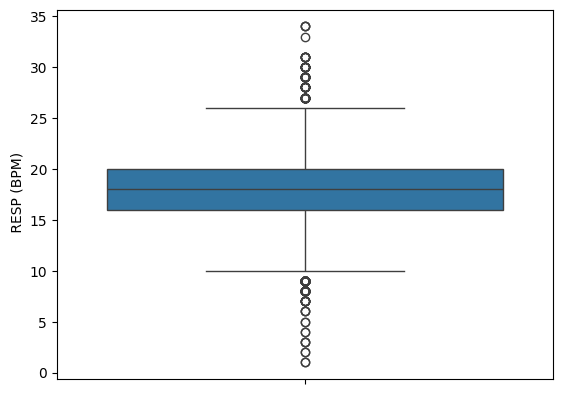

In [31]:
sns.boxplot(df[' RESP (BPM)'])

In [32]:
print(((df[' RESP (BPM)']<10)).sum())
print(((df[' RESP (BPM)']>30)).sum())

174
11


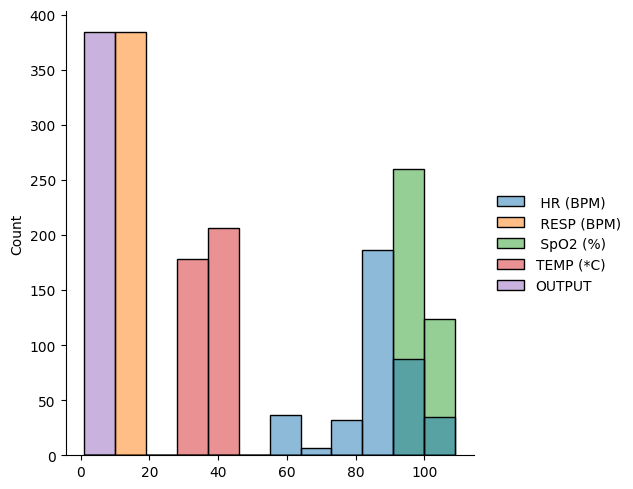

In [33]:
sns.displot(df[(df[' RESP (BPM)']>10)&(df[' RESP (BPM)']<12)& (df['OUTPUT']==1)])

In [34]:
(((df[' RESP (BPM)'] <= 30))&(df[' RESP (BPM)'] >= 10)).sum()
#20307-(11+174)=20122

np.int64(20122)

In [35]:
df=df[((df[' RESP (BPM)'] <= 30))&(df[' RESP (BPM)'] >= 10)]

In [36]:
df[' RESP (BPM)'].describe()

count    20122.000000
mean        17.918646
std          3.136443
min         10.000000
25%         16.000000
50%         18.000000
75%         20.000000
max         30.000000
Name:  RESP (BPM), dtype: float64

<Axes: ylabel=' RESP (BPM)'>

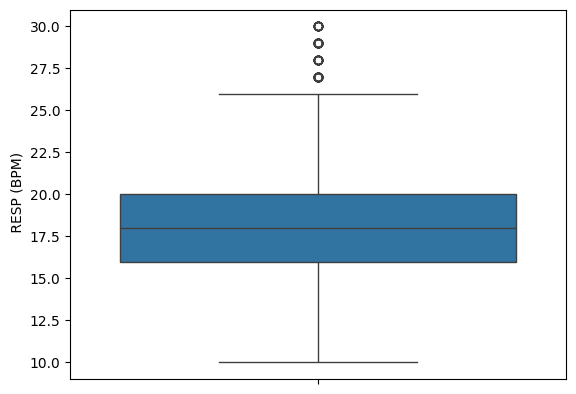

In [37]:
sns.boxplot(df[' RESP (BPM)'])

SPO2

<Axes: ylabel=' SpO2 (%)'>

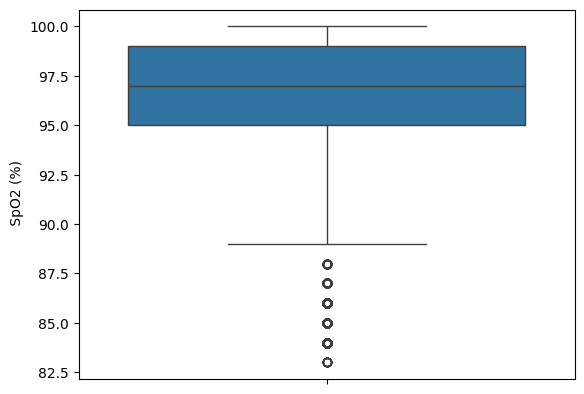

In [38]:
sns.boxplot(df[' SpO2 (%)'])

In [39]:
((df[' SpO2 (%)']<=87)&(df['OUTPUT']==1)).sum()

np.int64(648)

In [40]:
(((df[' SpO2 (%)']<=87)&(df['OUTPUT']==1))|(df[' SpO2 (%)']>87)).sum()
#20122-92=20030

np.int64(20030)

In [41]:
df=df[((df[' SpO2 (%)']<=87)&(df['OUTPUT']==1))|(df[' SpO2 (%)']>87)]

In [42]:
df[' SpO2 (%)'].describe()

count    20030.000000
mean        96.620519
std          3.213542
min         83.000000
25%         95.000000
50%         97.000000
75%         99.000000
max        100.000000
Name:  SpO2 (%), dtype: float64

<Axes: ylabel=' SpO2 (%)'>

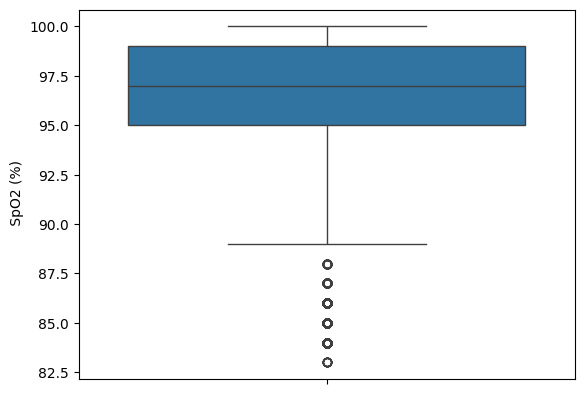

In [43]:
sns.boxplot(df[' SpO2 (%)'])

<Axes: >

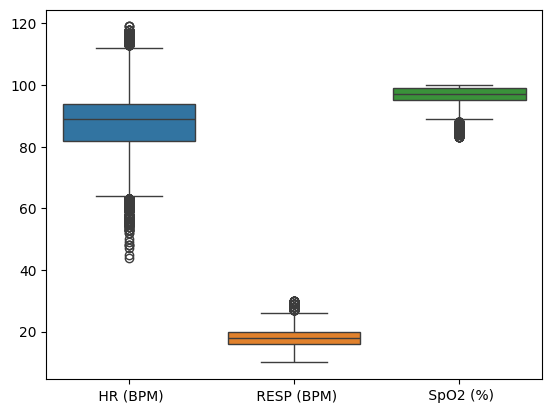

In [44]:
sns.boxplot(df[[' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)']])

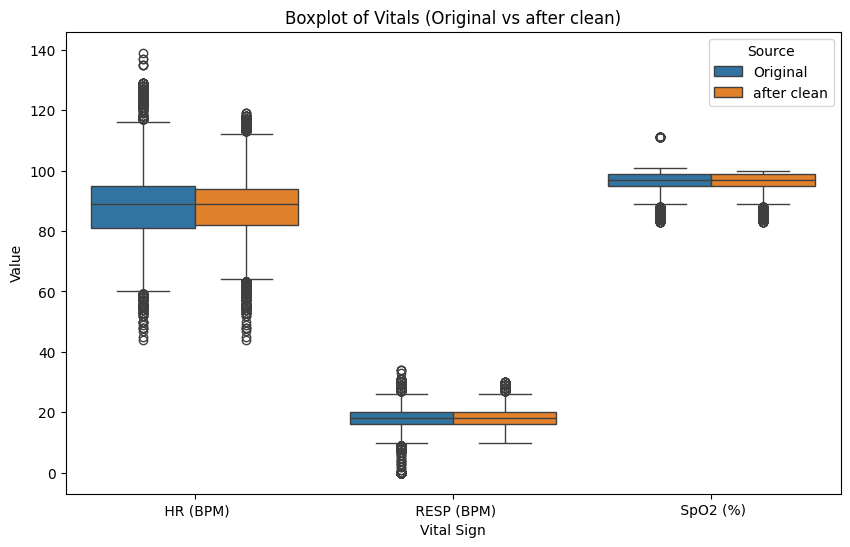

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a column to identify the source of data
df_out_labeled = df_out[[' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)']].copy()
df_out_labeled['Source'] = 'Original'

df_labeled = df[[' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)']].copy()
df_labeled['Source'] = 'after clean'

# Combine the two DataFrames
combined = pd.concat([ df_out_labeled,df_labeled])

# Melt the DataFrame to long-form for seaborn
melted = pd.melt(combined, id_vars='Source', var_name='Vital Sign', value_name='Value')

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Vital Sign', y='Value', hue='Source', data=melted)
plt.title('Boxplot of Vitals (Original vs after clean)')
plt.show()


In [46]:
def count_outliers_iqr(df):
    outlier_count = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count[col] = len(outliers)
    return outlier_count

# Count outliers in the DataFrame
outliers = count_outliers_iqr(df)
print("Outlier count per column:")
print(outliers)

Outlier count per column:
{' HR (BPM)': 1163, ' RESP (BPM)': 93, ' SpO2 (%)': 685, 'TEMP (*C)': 0, 'OUTPUT': 4480}


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20030 entries, 0 to 25492
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0    HR (BPM)    20030 non-null  float64
 1    RESP (BPM)  20030 non-null  float64
 2    SpO2 (%)    20030 non-null  float64
 3   TEMP (*C)    20030 non-null  float64
 4   OUTPUT       20030 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 938.9 KB


In [48]:
df['OUTPUT'].value_counts()

OUTPUT
1    15550
0     4480
Name: count, dtype: int64

In [46]:
print('spo2 normal value ',((df[' SpO2 (%)']>90)& (df['OUTPUT']==0)).sum())
# print('spo2 abnormal value ',((df[' SpO2 (%)']<95)& (df['OUTPUT']==1)).sum())

spo2 normal value  4480


In [49]:
print('resp normal value ', ((df[' RESP (BPM)'] > 11) & (df[' RESP (BPM)'] < 20) & (df['OUTPUT'] == 0)).sum())


resp normal value  3195


In [50]:
print('HR normal value ', ((df[' HR (BPM)'] > 60) & (df[' HR (BPM)'] < 100) & (df['OUTPUT'] == 0)).sum())

HR normal value  4152


In [51]:
print('normal range',((df[' SpO2 (%)']>=95) 
                      & (df[' RESP (BPM)'] >=12) & (df[' RESP (BPM)'] <= 20) &(df[' HR (BPM)'] >=70) & (df[' HR (BPM)'] <= 90) &  (df['OUTPUT']==0)).sum())

normal range 2152


In [52]:
condation=((df[' SpO2 (%)']>=95)&
             (df[' RESP (BPM)'] >= 12) & 
                      (df[' RESP (BPM)'] <= 20) &
                      (df[' HR (BPM)'] >= 70) & 
                      (df[' HR (BPM)'] <=90 ) &  (df['OUTPUT']==0))

In [53]:
df1=df[condation]

In [54]:
df1.describe()

,HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
count,2152.000000,2152.000000,2152.000000,2152.000000,2152.0
mean,82.235595,17.069238,97.804368,31.123141,0.0
std,5.879131,1.947317,1.957075,1.593858,0.0
min,70.000000,12.000000,95.000000,29.000000,0.0
25%,77.000000,16.000000,96.000000,30.000000,0.0
50%,83.000000,17.000000,98.000000,31.000000,0.0
75%,89.000000,18.000000,100.000000,32.000000,0.0
max,90.000000,20.000000,100.000000,35.000000,0.0


In [55]:
print('resp abnormal',(((df[' RESP (BPM)'] <= 12) | (df[' RESP (BPM)'] >= 20)) & (df['OUTPUT'] == 1)).sum())

print('HR abnormal',(((df[' HR (BPM)'] < 60) | (df[' HR (BPM)'] >= 100)) & (df['OUTPUT'] == 1)).sum())
print('spo2 abnormal value ',((df[' SpO2 (%)']<95)& (df['OUTPUT']==1)).sum())

resp abnormal 4898
HR abnormal 3054
spo2 abnormal value  3678


In [56]:
print('abnormal_count',
    (((df[' SpO2 (%)'] < 95) |
     (df[' RESP (BPM)'] < 12) | (df[' RESP (BPM)'] > 20) |
     (df[' HR (BPM)'] < 75) | (df[' HR (BPM)'] > 90))
    &(df['OUTPUT'] == 1)).sum())

abnormal_count 10894


In [57]:
condition2=((df[' SpO2 (%)'] < 95) |
     (df[' RESP (BPM)'] < 12) | (df[' RESP (BPM)'] >20) |
     (df[' HR (BPM)'] <= 75) | (df[' HR (BPM)'] >= 95)) &(df['OUTPUT'] == 1)

In [58]:
df2=df[condition2]

In [59]:
df2.describe()

,HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
count,10023.000000,10023.000000,10023.000000,10023.000000,10023.0
mean,89.909708,18.188167,95.701786,38.771625,1.0
std,14.740533,3.470190,3.827158,2.486328,0.0
min,44.000000,10.000000,83.000000,29.000000,1.0
25%,80.000000,16.000000,93.000000,37.000000,1.0
50%,91.000000,18.000000,97.000000,39.000000,1.0
75%,101.000000,20.000000,98.000000,41.000000,1.0
max,119.000000,30.000000,100.000000,43.000000,1.0


In [60]:
df_cleaned = pd.concat([df1, df2], ignore_index=True)


In [61]:
df_cleaned['OUTPUT'].value_counts()

OUTPUT
1    10023
0     2152
Name: count, dtype: int64

In [62]:
df.columns

Index([' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)', 'TEMP (*C)', 'OUTPUT'], dtype='object')

In [63]:
df.describe()

,HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
count,20030.000000,20030.000000,20030.000000,20030.000000,20030.000000
mean,88.536695,17.887569,96.620519,37.073879,0.776335
std,11.574898,3.109617,3.213542,4.127471,0.416710
min,44.000000,10.000000,83.000000,29.000000,0.000000
25%,82.000000,16.000000,95.000000,34.250000,1.000000
50%,89.000000,18.000000,97.000000,38.000000,1.000000
75%,94.000000,20.000000,99.000000,41.000000,1.000000
max,119.000000,30.000000,100.000000,43.000000,1.000000


In [64]:
df_cleaned.describe()

,HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
count,12175.000000,12175.000000,12175.000000,12175.000000,12175.000000
mean,88.553265,17.990390,96.073429,37.419713,0.823244
std,13.912277,3.281116,3.657601,3.748471,0.381477
min,44.000000,10.000000,83.000000,29.000000,0.000000
25%,79.000000,16.000000,93.000000,35.000000,1.000000
50%,88.000000,18.000000,97.000000,38.000000,1.000000
75%,99.000000,20.000000,99.000000,40.000000,1.000000
max,119.000000,30.000000,100.000000,43.000000,1.000000


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

In [66]:
# df_cleaned['**RESP (BPM)']=df_cleaned[ ' RESP (BPM)']**2

In [93]:
X=df_cleaned[[' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)']]
y=df_cleaned[['OUTPUT']]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [95]:
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# y_resampled.value_counts()

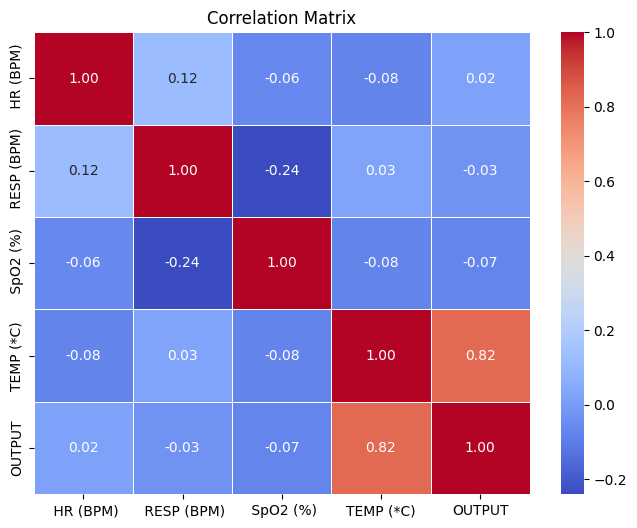

In [96]:
correlation_matrix =df.corr()

# رسم خريطة الارتباط باستخدام Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [97]:
# 1. Import libraries
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix

# 5. Create and train the model
lo_re = LogisticRegression(max_iter=1000)
lo_re.fit(X_train, y_train)

# 6. Make predictions
y_pred = lo_re.predict(X_test)

# 7. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)



Accuracy: 0.801259238981659


c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


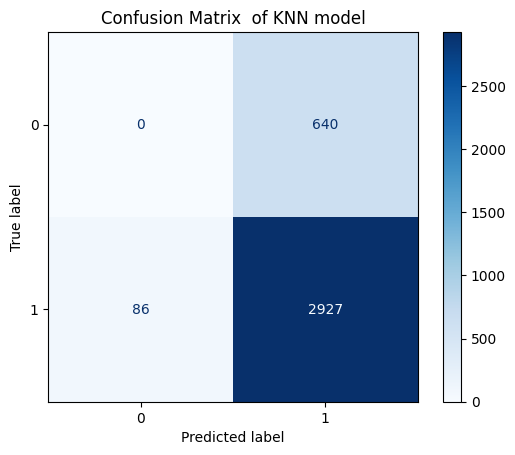

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score ,classification_report
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix  of KNN model')
plt.show()

In [99]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)  


In [100]:
model.fit(X_train,y_train )

c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [101]:
y_pred = model.predict(X_test)

In [102]:


print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Confusion Matrix:
 [[ 576   64]
 [  26 2987]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       640
           1       0.98      0.99      0.99      3013

    accuracy                           0.98      3653
   macro avg       0.97      0.95      0.96      3653
weighted avg       0.98      0.98      0.98      3653



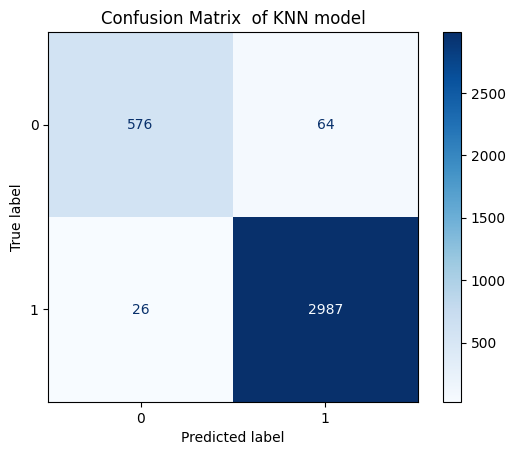

In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score ,classification_report
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix  of KNN model')
plt.show()

In [104]:
model.predict([[72,12,95]])

c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [77]:
X_test

array([[ 0.3781458 ,  1.29533889,  0.50054468],
       [ 0.84205288,  0.65575809,  1.07827019],
       [-1.01357541,  0.65575809, -0.9437691 ],
       ...,
       [-0.93625757,  0.65575809, -0.9437691 ],
       [-2.09602525, -0.62340351,  1.07827019],
       [-2.0187074 , -0.62340351,  1.07827019]], shape=(4270, 3))

In [134]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# إنشاء النموذج مع موازنة الفئات تلقائيًا
model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200)

# تدريب النموذج
model.fit(X_train, y_train)

# التنبؤ على مجموعة الاختبار
y_pred = model.predict(X_test)

# عرض تقرير التصنيف
print("Classification Report:")
print(classification_report(y_test, y_pred))

# مصفوفة الارتباك (Confusion Matrix)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       640
           1       1.00      0.97      0.98      3013

    accuracy                           0.97      3653
   macro avg       0.94      0.98      0.95      3653
weighted avg       0.98      0.97      0.97      3653

Confusion Matrix:
[[ 630   10]
 [  90 2923]]


In [129]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# إنشاء نموذج SVM مع موازنة الفئات
model = SVC(C=2, gamma='scale', kernel='rbf')

# تدريب النموذج
model.fit(X_train, y_train)

# التنبؤ على مجموعة الاختبار
y_pred = model.predict(X_test)

# عرض تقرير التصنيف
print("Classification Report:")
print(classification_report(y_test, y_pred))

# مصفوفة الارتباك
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.41      0.51       640
           1       0.88      0.96      0.92      3013

    accuracy                           0.86      3653
   macro avg       0.78      0.68      0.72      3653
weighted avg       0.85      0.86      0.85      3653

Confusion Matrix:
[[ 261  379]
 [ 122 2891]]


In [1416]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, f1_score

# إنشاء النموذج
knn = KNeighborsClassifier(n_neighbors=5)

scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')


f1 = cross_val_score(knn, X, y, cv=5, scoring='f1_macro')  # أو f1_weighted


c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConv

In [1417]:
print("F1 Macro scores:", f1)
print("Mean F1 Macro:", f1.mean())

F1 Macro scores: [0.65296319 0.8772373  0.63930116 0.66721944 0.88812527]
Mean F1 Macro: 0.7449692715979759


In [1418]:
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.78468563 0.94063927 0.75237092 0.8092059  0.94096978]
Mean accuracy: 0.845574301066749


In [91]:
import joblib

joblib.dump(model, 'C:\\Users\\LoQ\\Desktop\\new_ vital sign\\model.pki')


['C:\\Users\\LoQ\\Desktop\\new_ vital sign\\model.pki']

In [113]:
df_val=pd.read_csv('C:\\Users\\LoQ\\Desktop\\vital_sign\\human_vital_signs_dataset_2024.csv')

In [114]:
df_val['Risk Category'] = df_val['Risk Category'].replace({'High Risk': 1, 'Low Risk': 0})

C:\Users\LoQ\AppData\Local\Temp\ipykernel_13436\1367340113.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_val['Risk Category'] = df_val['Risk Category'].replace({'High Risk': 1, 'Low Risk': 0})


In [115]:
df_val.columns

Index(['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Timestamp',
       'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'Risk Category'],
      dtype='object')

In [116]:
df_val = df_val.rename(columns={ 'Heart Rate':' HR (BPM)',
                                'Respiratory Rate' :' RESP (BPM)',
                                  'Oxygen Saturation':' SpO2 (%)', 
                                   'Risk Category': 'OUTPUT'})

In [117]:
df_val.columns

Index(['Patient ID', ' HR (BPM)', ' RESP (BPM)', 'Timestamp',
       'Body Temperature', ' SpO2 (%)', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'OUTPUT'],
      dtype='object')

In [118]:
df_val[[' HR (BPM)', ' RESP (BPM)',' SpO2 (%)']].describe()

,HR (BPM),RESP (BPM),SpO2 (%)
count,200020.000000,200020.000000,200020.000000
mean,79.533747,15.489451,97.504372
std,11.552894,2.294472,1.442598
min,60.000000,12.000000,95.000007
25%,70.000000,13.000000,96.256859
50%,80.000000,15.000000,97.509629
75%,90.000000,17.000000,98.755722
max,99.000000,19.000000,99.999963


In [119]:
df_val.columns

Index(['Patient ID', ' HR (BPM)', ' RESP (BPM)', 'Timestamp',
       'Body Temperature', ' SpO2 (%)', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'OUTPUT'],
      dtype='object')

In [120]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Patient ID                200020 non-null  int64  
 1    HR (BPM)                 200020 non-null  int64  
 2    RESP (BPM)               200020 non-null  int64  
 3   Timestamp                 200020 non-null  object 
 4   Body Temperature          200020 non-null  float64
 5    SpO2 (%)                 200020 non-null  float64
 6   Systolic Blood Pressure   200020 non-null  int64  
 7   Diastolic Blood Pressure  200020 non-null  int64  
 8   Age                       200020 non-null  int64  
 9   Gender                    200020 non-null  object 
 10  Weight (kg)               200020 non-null  float64
 11  Height (m)                200020 non-null  float64
 12  Derived_HRV               200020 non-null  float64
 13  Derived_Pulse_Pressure    200020 non-null  i

In [121]:
df_val.columns

Index(['Patient ID', ' HR (BPM)', ' RESP (BPM)', 'Timestamp',
       'Body Temperature', ' SpO2 (%)', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'OUTPUT'],
      dtype='object')

<Axes: xlabel=' HR (BPM)', ylabel='Count'>

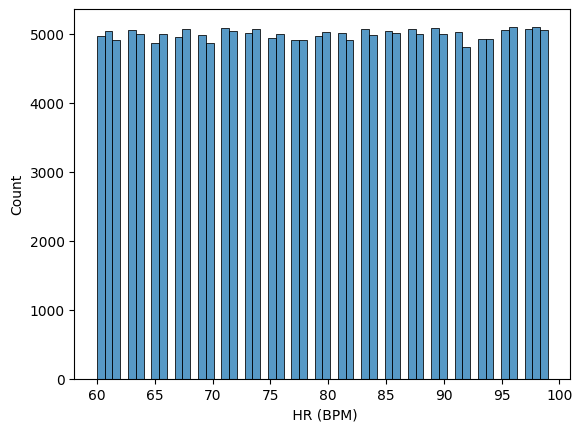

In [122]:
sns.histplot(df_val[' HR (BPM)'])

In [170]:
abnormal_count =((df_val[' SpO2 (%)'] < 95) |
     (df_val[' RESP (BPM)'] < 12) | (df_val[' RESP (BPM)'] >20) |
     (df_val[' HR (BPM)'] < 70) | (df_val[' HR (BPM)'] > 90)) &(df_val['OUTPUT'] == 1)

print('abnormal_count:', abnormal_count.sum())

abnormal_count: 64563


In [ ]:
normal_count=((df_val[' SpO2 (%)']> 95)&
             (df_val[' RESP (BPM)'] > 12) & 
                      (df_val[' RESP (BPM)'] < 20) &
                      (df_val[' HR (BPM)'] > 70) & 
                      (df_val[' HR (BPM)'] < 90 ) &  (df_val['OUTPUT']==0))
print('normal range',normal_count.sum())

normal range 50990


In [183]:
df_val2=df_val[abnormal_count]

In [184]:
df_val1=df_val[normal_count]

In [185]:
df_val_cleaned = pd.concat([df_val1, df_val2], ignore_index=True)

In [186]:
x_val=df_val_cleaned[[' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)',]]
y_val=df_val_cleaned[[ 'OUTPUT']]             

In [187]:
x_val.describe()

,HR (BPM),RESP (BPM),SpO2 (%)
count,115553.000000,115553.000000,115553.000000
mean,83.261361,15.713404,97.502514
std,11.631451,2.185373,1.445138
min,60.000000,12.000000,95.000042
25%,74.000000,14.000000,96.252033
50%,85.000000,16.000000,97.508058
75%,94.000000,18.000000,98.759831
max,99.000000,19.000000,99.999928


In [188]:
y_val_pre=model.predict(x_val)

In [189]:
y_val.value_counts()

OUTPUT
1         64563
0         50990
Name: count, dtype: int64

In [193]:
print("Accuracy:", accuracy_score(y_val, y_val_pre))

Accuracy: 0.9110278400387701


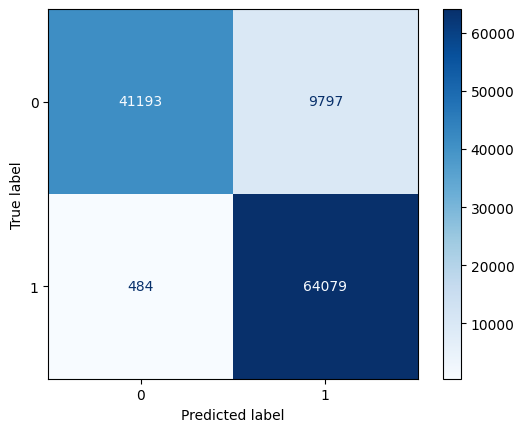

In [191]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score ,classification_report
cm = confusion_matrix(y_val, y_val_pre)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [192]:
print("Classification Report:")
print(classification_report(y_val, y_val_pre))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     50990
           1       0.87      0.99      0.93     64563

    accuracy                           0.91    115553
   macro avg       0.93      0.90      0.91    115553
weighted avg       0.92      0.91      0.91    115553



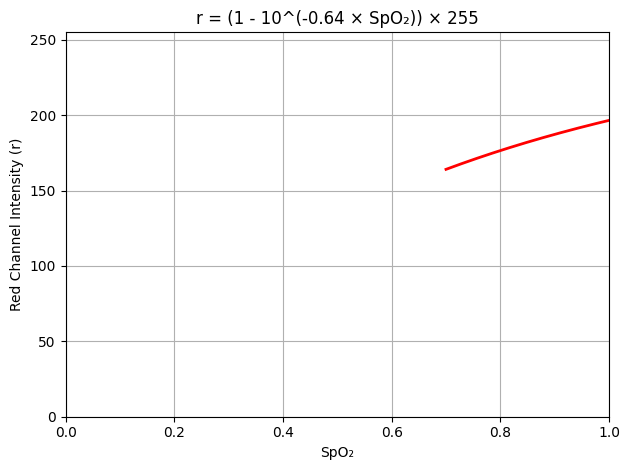

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# توليد بيانات SpO₂ من 0.7 إلى 1 فقط
spo2 = np.linspace(0.7, 1, 300)
r = (1 - 10**(-0.64 * spo2)) * 255

# رسم المعادلة من 0.7 إلى 1 فقط، بلون موحد
plt.plot(spo2, r, color='red', linewidth=2)

# إعدادات الشكل
plt.title("r = (1 - 10^(-0.64 × SpO₂)) × 255")
plt.xlabel("SpO₂")
plt.ylabel("Red Channel Intensity (r)")
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, 255)
plt.tight_layout()
plt.show()
